In [1]:
import NN_model_helper
import numpy as np, pandas as pd, optuna, torch
from sklearn.model_selection import StratifiedKFold
from NN_model import ImprovedNN 
from pathlib import Path
import json, torch
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from NN_model_helper import (evaluate_fold, plot_training_progress, find_optimal_clusters)

import sys
from pathlib import Path

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_60(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_fr_azide,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9
0,OC(=O)C(CCl)Cl,50.0,Train,0,-0.654237,-0.158241,-0.709125,-1.262370,-0.108535,-0.654678,...,-0.026038,-0.637920,-0.036835,-0.450835,-0.036961,-0.455798,-1.192190,-0.151018,-1.024159,-0.952553
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,-0.026038,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553
2,COC(=O)c1ccc(cc1[N+](=O)[O-])C(=O)O,175.0,Train,0,1.461234,0.542313,-0.709125,-0.516638,0.390127,0.393353,...,-0.026038,-1.121697,-0.036835,-0.219191,0.098131,-0.455798,-0.295318,1.236425,-0.240879,1.043138
3,COC(=O)c1cccc(c1)O,71.0,Train,0,0.403499,0.683312,-0.709125,-0.820480,0.280962,-0.654678,...,-0.026038,-0.257927,-0.036835,-0.213605,0.098131,-0.455798,-0.883738,0.303652,-0.936669,0.484767
4,OC(=O)c1cc(F)cc(c1)F,121.0,Train,0,2.340660,-0.158241,-0.709125,-0.852599,0.786887,0.550866,...,-0.026038,-0.239395,-0.036835,0.861591,-0.682878,-0.455798,-0.957290,0.691814,-0.879925,-0.321582


In [3]:
df_train = df[
    (df["Type"] == "Train") &
    (df["MW_label"] == 1)
].copy()

print("Shape:", df_train.shape)
print(df_train[["Type", "MW_label"]].value_counts())

Shape: (4132, 144)
Type   MW_label
Train  1           4132
Name: count, dtype: int64


In [4]:
df_train.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_fr_azide,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,-0.026038,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553
7,Brc1cc(F)c(c(c1)Br)N,63.0,Train,1,0.314344,-0.158241,-0.709125,-0.926190,0.915875,-0.051906,...,-0.026038,0.850406,-0.036835,0.291459,-0.053036,-0.455798,-0.639734,-0.679960,0.176126,-0.307526
8,N#Cc1ccc(c(c1)[N+](=O)[O-])/C=C/c1ccc(cc1)/C=C...,350.0,Train,1,-0.654237,-0.158241,-0.069217,1.048834,0.420616,3.789611,...,-0.026038,-1.121666,-0.036835,-0.450835,-0.682878,-0.455798,1.878875,-0.156244,1.638947,4.064742
9,OC1CCC2(C(=CC(=O)C3C2CCC2(C3CCC2=O)C)C1)C,238.0,Train,1,-0.654237,-0.158241,-0.388813,1.834903,0.985228,2.307123,...,-0.026038,-0.644885,-0.036835,-0.450835,-0.682878,3.518967,0.693254,0.309188,0.495425,-0.260280
11,OC(=O)CC[C@H]([C@H]1CC[C@@H]2[C@]1(C)C(=O)C[C@...,237.0,Train,1,-0.654237,-0.158241,-0.709125,2.780696,1.244354,4.146738,...,-0.026038,-0.697293,-0.036835,-0.450835,-0.682878,3.518967,1.647585,1.229600,1.449587,-0.952553


X_scaled shape: (4132, 140)
Num features: 140


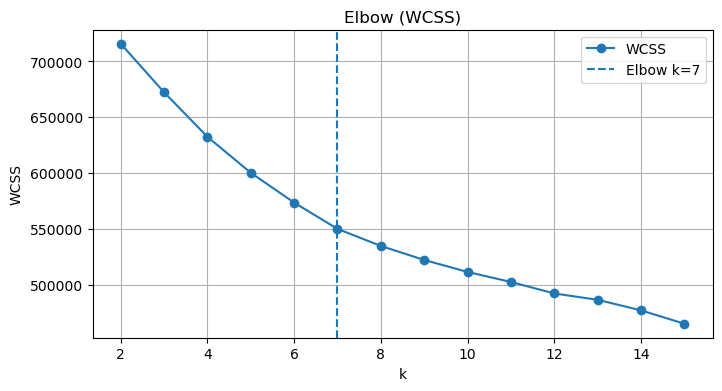

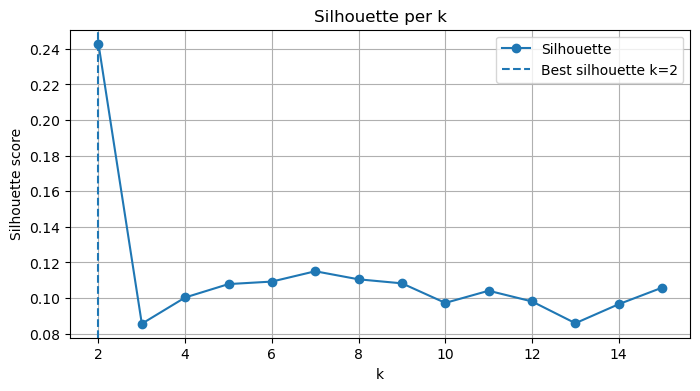

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "MW_label"}
num_cols = df_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_train[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_train), "Cluster labels length != df rows (mismatch)."

df_clustered = df_train.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [6]:
df_clustered.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9,Structure_Cluster
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553,0
7,Brc1cc(F)c(c(c1)Br)N,63.0,Train,1,0.314344,-0.158241,-0.709125,-0.926190,0.915875,-0.051906,...,0.850406,-0.036835,0.291459,-0.053036,-0.455798,-0.639734,-0.679960,0.176126,-0.307526,0
8,N#Cc1ccc(c(c1)[N+](=O)[O-])/C=C/c1ccc(cc1)/C=C...,350.0,Train,1,-0.654237,-0.158241,-0.069217,1.048834,0.420616,3.789611,...,-1.121666,-0.036835,-0.450835,-0.682878,-0.455798,1.878875,-0.156244,1.638947,4.064742,5
9,OC1CCC2(C(=CC(=O)C3C2CCC2(C3CCC2=O)C)C1)C,238.0,Train,1,-0.654237,-0.158241,-0.388813,1.834903,0.985228,2.307123,...,-0.644885,-0.036835,-0.450835,-0.682878,3.518967,0.693254,0.309188,0.495425,-0.260280,4
11,OC(=O)CC[C@H]([C@H]1CC[C@@H]2[C@]1(C)C(=O)C[C@...,237.0,Train,1,-0.654237,-0.158241,-0.709125,2.780696,1.244354,4.146738,...,-0.697293,-0.036835,-0.450835,-0.682878,3.518967,1.647585,1.229600,1.449587,-0.952553,4


Fold split & Optimization

In [7]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "MW_label", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 4132
Num features: 140
Num folds: 10

Fold  0 | Train: 3718 | Val:  414
Fold  1 | Train: 3718 | Val:  414
Fold  2 | Train: 3719 | Val:  413
Fold  3 | Train: 3719 | Val:  413
Fold  4 | Train: 3719 | Val:  413
Fold  5 | Train: 3719 | Val:  413
Fold  6 | Train: 3719 | Val:  413
Fold  7 | Train: 3719 | Val:  413
Fold  8 | Train: 3719 | Val:  413
Fold  9 | Train: 3719 | Val:  413


In [8]:
import time
import numpy as np
from pathlib import Path

trial_times = []

def objective(trial):
    dropout_rate  = trial.suggest_float("dropout_rate",  0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay",  1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])

    h1 = trial.suggest_categorical("h1", [64, 96, 128, 160, 192, 224, 256])
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    hidden_layers = [h1, h2, h3]

    start = time.perf_counter()
    rmses = []

    for fold_idx, (tr_idx, val_idx) in enumerate(folds):
        X_train_scaled = X[tr_idx]
        y_train        = y[tr_idx]
        X_val_scaled   = X[val_idx]
        y_val          = y[val_idx]

        rmse, *_ = evaluate_fold(
            trial=trial,
            fold_idx=fold_idx,
            X_train_scaled=X_train_scaled,
            y_train=y_train,
            X_val_scaled=X_val_scaled,
            y_val=y_val,
            learning_rate=learning_rate,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
            weight_decay=weight_decay,
            save_checkpoints=False,
            checkpoint_dir=None,   # <- no checkpoints
        )
        rmses.append(float(rmse))

    elapsed_min = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed_min)

    avg_rmse = float(np.mean(rmses))

    # Save for later plotting/analysis
    trial.set_user_attr("avg_rmse", avg_rmse)
    trial.set_user_attr("fold_rmses", rmses)
    trial.set_user_attr("elapsed_min", elapsed_min)

    print(f"Trial {trial.number} finished in {elapsed_min:.2f} minutes")
    print(f"Trial {trial.number}: Average RMSE = {avg_rmse:.4f}")

    return avg_rmse

def set_optuna_study(n_trials): 
    start_time = time.perf_counter()
    print("Setting up Optuna study...")
    
    # 1) Set up the Optuna study
    study = optuna.create_study(direction='minimize') #minimize return loss
    study.optimize(objective, n_trials=n_trials)  #CHANGE TO 100 AFTER TESTING
    
    # 2) Identify the best hyperparameters
    best_params = study.best_params #best_params holds the dropout, learning rate, and weight decay that gave the lowest best_val_loss
    print("Best hyperparameters:", best_params)
    
    end_time = time.perf_counter()
    elapsed_time = (end_time - start_time) / 60.0
    print(f"Optuna study completed in {elapsed_time:.2f} minutes")
    
    return best_params, study


device = torch.device("cpu")
best_params, study = set_optuna_study(n_trials=20)

[I 2026-03-01 17:40:54,652] A new study created in memory with name: no-name-9e2a6a3c-e407-44dc-ac7f-d8e9539ee59b


Setting up Optuna study...
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 168.4363 | Val Loss: 168.8887 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 166.1428 | Val Loss: 167.3256 | ES 1/30
[Fold 0] Epoch  100 | Train Loss: 163.5080 | Val Loss: 164.7941 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 160.2969 | Val Loss: 161.5670 | ES 0/30
[Fold 0] Epoch  200 | Train Loss: 156.9123 | Val Loss: 157.8923 | ES 1/30
[Fold 0] Epoch  250 | Train Loss: 154.8313 | Val Loss: 155.7295 | ES 13/30
[Fold 0] Early stopping  at epoch 289 (best Val Loss: 154.6156)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 167.8932 | Val Loss: 169.3865 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 165.4188 | Val Loss: 167.7379 | ES 1/30
[Fold 1] Epoch  100 | Train Loss: 162.8380 | Val Loss: 165.6233 | ES 4/30
[Fold 1] Epoch  150 | Train Loss: 159.3945 | Val Loss: 162.4784 | ES 2/30
[Fold 1] Epoch  200 | Train Loss: 155.4102 | Val Loss: 158.2246 | ES 3/30
[Fold 1] Epoch  250 | Train Loss: 150.7861 | V

[I 2026-03-01 17:50:15,070] Trial 0 finished with value: 141.14088973999023 and parameters: {'dropout_rate': 0.37293759000769444, 'learning_rate': 1.578137780172422e-05, 'weight_decay': 4.687477871787334e-06, 'batch_size': 32, 'h1': 160}. Best is trial 0 with value: 141.14088973999023.


[Fold 9] Early stopping  at epoch 362 (best Val Loss: 143.6952)
Trial 0 finished in 9.34 minutes
Trial 0: Average RMSE = 141.1409
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 168.0855 | Val Loss: 168.4113 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 76.2335 | Val Loss: 73.3025 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 46.0920 | Val Loss: 37.8838 | ES 2/30
[Fold 0] Early stopping  at epoch 137 (best Val Loss: 37.3370)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 167.8737 | Val Loss: 169.5474 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 76.4348 | Val Loss: 76.7104 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 45.7931 | Val Loss: 40.9817 | ES 2/30
[Fold 1] Epoch  150 | Train Loss: 44.9333 | Val Loss: 40.7248 | ES 25/30
[Fold 1] Early stopping  at epoch 155 (best Val Loss: 39.0831)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 168.1569 | Val Loss: 164.7819 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 75.7860 | Val Loss: 71.0361 | ES 0/30
[Fold 2] Epoch  1

[I 2026-03-01 17:53:34,795] Trial 1 finished with value: 39.968841552734375 and parameters: {'dropout_rate': 0.37628032988831905, 'learning_rate': 0.00025698282087016237, 'weight_decay': 0.0016261849791478979, 'batch_size': 32, 'h1': 160}. Best is trial 1 with value: 39.968841552734375.


...

[Fold 9] Early stopping  at epoch 258 (best Val Loss: 37.6169)
Trial 17 finished in 2.22 minutes
Trial 17: Average RMSE = 39.9313
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 167.3452 | Val Loss: 166.5766 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 38.1256 | Val Loss: 38.9976 | ES 2/30
[Fold 0] Early stopping  at epoch 100 (best Val Loss: 37.9582)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 166.5016 | Val Loss: 167.6468 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 36.8589 | Val Loss: 38.9545 | ES 1/30
[Fold 1] Epoch  100 | Train Loss: 33.4567 | Val Loss: 38.3178 | ES 2/30
[Fold 1] Early stopping  at epoch 139 (best Val Loss: 37.8108)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 167.9247 | Val Loss: 163.2519 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 37.3654 | Val Loss: 40.9033 | ES 1/30
[Fold 2] Early stopping  at epoch 96 (best Val Loss: 39.7138)
Fold 3: Training on cpu
[Fold 3] Epoch    1 | Train Loss: 167.1735 | Val Loss: 163.4404 | ES 0/30
[F

[I 2026-03-01 19:48:39,014] Trial 18 finished with value: 39.1571849822998 and parameters: {'dropout_rate': 0.2886066159089811, 'learning_rate': 0.0008908565074952464, 'weight_decay': 0.0006528843473658508, 'batch_size': 64, 'h1': 224}. Best is trial 13 with value: 39.01769905090332.


[Fold 9] Early stopping  at epoch 126 (best Val Loss: 36.5001)
Trial 18 finished in 3.04 minutes
Trial 18: Average RMSE = 39.1572
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 167.7327 | Val Loss: 167.3003 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 53.6145 | Val Loss: 52.7598 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 35.2549 | Val Loss: 37.2929 | ES 15/30
[Fold 0] Early stopping  at epoch 115 (best Val Loss: 36.9842)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 168.0301 | Val Loss: 169.3010 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 55.7950 | Val Loss: 56.2004 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 37.0182 | Val Loss: 39.5260 | ES 23/30
[Fold 1] Epoch  150 | Train Loss: 36.1037 | Val Loss: 38.8637 | ES 9/30
[Fold 1] Early stopping  at epoch 171 (best Val Loss: 38.8273)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 167.6979 | Val Loss: 163.6828 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 53.0281 | Val Loss: 55.4861 | ES 0/30
[Fold 2] Epoch  

[I 2026-03-01 19:52:26,010] Trial 19 finished with value: 39.32462921142578 and parameters: {'dropout_rate': 0.28586536223052933, 'learning_rate': 0.0004855544459133399, 'weight_decay': 0.0006122461930685767, 'batch_size': 64, 'h1': 224}. Best is trial 13 with value: 39.01769905090332.


[Fold 9] Early stopping  at epoch 118 (best Val Loss: 37.0835)
Trial 19 finished in 3.78 minutes
Trial 19: Average RMSE = 39.3246
Best hyperparameters: {'dropout_rate': 0.3056401610933022, 'learning_rate': 0.0007003227358122579, 'weight_decay': 0.0005860003777224081, 'batch_size': 64, 'h1': 192}
Optuna study completed in 131.52 minutes


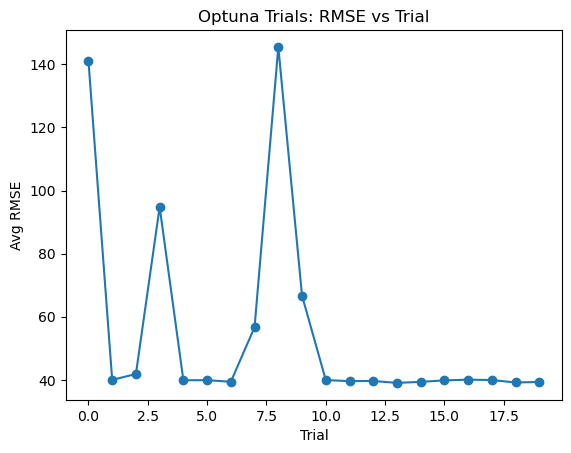

In [9]:
import matplotlib.pyplot as plt

df_trials = study.trials_dataframe(attrs=("number", "value", "user_attrs"))
rmse_by_trial = df_trials["value"].to_numpy()   # value == returned avg_rmse
trial_nums = df_trials["number"].to_numpy()

plt.figure()
plt.plot(trial_nums, rmse_by_trial, marker="o")
plt.xlabel("Trial")
plt.ylabel("Avg RMSE")
plt.title("Optuna Trials: RMSE vs Trial")
plt.show()


In [10]:
# Save the best parameters

print("Best Trial Number:", study.best_trial.number)
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

Best Trial Number: 13
  RMSE: 39.01769905090332
  Params: {'dropout_rate': 0.3056401610933022, 'learning_rate': 0.0007003227358122579, 'weight_decay': 0.0005860003777224081, 'batch_size': 64, 'h1': 192}


In [11]:
# Retrain and Save Models with Best Hyperparameters

BASE = Path.cwd()  
artifacts_dir = BASE / "artifacts_threshold"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "general_best_HighMW_RDKit_60(split)_MW(label)_60(threshold)"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_general_best_HighMW_RDKit_60(split)_MW(label)_60(threshold)"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Make sure best_params exists (from your Optuna study: best_params, study = set_optuna_study(...))
print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

# To keep track of metrics across folds
final_fold_metrics = []

# ---------- Final training loop for all folds (using `folds`, X, y) ----------
# Assumes you already defined:
#   X, y, folds = [(tr_idx, val_idx), ...] earlier (same as in `objective`)
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    # Slice the global X, y using the same folds as during Optuna
    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    # Train this fold with the best hyperparameters
    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,                    # not needed for final run
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,              # will stop via early-stopping anyway
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,         # save checkpoints for this BEST config
        checkpoint_dir=final_ckpt_dir, # root; evaluate_fold will create fold_{k}/ inside
        save_every_n_epochs=15
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"general_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best model to: {model_path}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "general_best_HighMW_RDKit_60(split)_MW(label)_60(threshold).csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.3056401610933022, 'learning_rate': 0.0007003227358122579, 'weight_decay': 0.0005860003777224081, 'batch_size': 64, 'h1': 192}
Using hidden_layers: [192, 96, 48]
dropout: 0.3056401610933022 | lr: 0.0007003227358122579 | wd: 0.0005860003777224081 | batch_size: 64

==================== Final training for fold 0 ====================
Fold 0: Training on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/checkpoints_general_best_HighMW_RDKit_60(split)_MW(label)_60(threshold)/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 167.1285
[Fold 0] Epoch    1 | Train Loss: 166.8683 | Val Loss: 166.5947 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 131.2369
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 73.9859
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 42.6725
[Fold 0] Epoch   50 | Train Loss: 42.4638 | Val Loss: 40.7131 | ES 2/30
[Fold 0] Regular checkpoint saved 

TEST SET EVALUATION

In [22]:
data_prefix_MW = '../MW/artifacts_threshold/'

df = pd.read_parquet(data_prefix_MW + "scaled_final_dataset_RDKit_60(split)_MW(label)_60(threshold).parquet")
df.head()

,SMILES,MP,Type,MW_label,RDKit_PEOE_VSA3,RDKit_VSA_EState9,RDKit_EState_VSA7,RDKit_Chi2n,RDKit_MaxAbsEStateIndex,RDKit_SlogP_VSA4,...,RDKit_fr_azide,RDKit_BCUT2D_MRLOW,RDKit_fr_quatN,RDKit_VSA_EState1,RDKit_SMR_VSA6,RDKit_fr_bicyclic,RDKit_LabuteASA,RDKit_SMR_VSA1,RDKit_MolWt,RDKit_PEOE_VSA9
0,OC(=O)C(CCl)Cl,50.0,Train,0,-0.654237,-0.158241,-0.709125,-1.262370,-0.108535,-0.654678,...,-0.026038,-0.637920,-0.036835,-0.450835,-0.036961,-0.455798,-1.192190,-0.151018,-1.024159,-0.952553
1,BrCc1c(CBr)c(CBr)c(c(c1CBr)CBr)CBr,292.0,Train,1,-0.654237,-0.158241,-0.709125,-0.154195,-2.227378,-0.654678,...,-0.026038,1.743540,-0.036835,-0.450835,-0.682878,-0.455798,1.326878,-1.101377,3.671337,-0.952553
2,COC(=O)c1ccc(cc1[N+](=O)[O-])C(=O)O,175.0,Train,0,1.461234,0.542313,-0.709125,-0.516638,0.390127,0.393353,...,-0.026038,-1.121697,-0.036835,-0.219191,0.098131,-0.455798,-0.295318,1.236425,-0.240879,1.043138
3,COC(=O)c1cccc(c1)O,71.0,Train,0,0.403499,0.683312,-0.709125,-0.820480,0.280962,-0.654678,...,-0.026038,-0.257927,-0.036835,-0.213605,0.098131,-0.455798,-0.883738,0.303652,-0.936669,0.484767
4,OC(=O)c1cc(F)cc(c1)F,121.0,Train,0,2.340660,-0.158241,-0.709125,-0.852599,0.786887,0.550866,...,-0.026038,-0.239395,-0.036835,0.861591,-0.682878,-0.455798,-0.957290,0.691814,-0.879925,-0.321582


In [23]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (6888, 144)


In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts_threshold/general_best_LowMW_RDKit_60(split)_MW(label)_60(threshold)/general_best_fold_4.pt"

OUT_PRED_CSV = BASE / "artifacts_threshold/test_general_predictions_lowMW_RDKit_60(split)_MW(label)_60(threshold).csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.3054635513289601

NON_FEATURES = ["SMILES", "MP", "Type", "MW_label"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "MW_label": df_test["MW_label"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 6888
Features: 140

=== TEST METRICS ===
RMSE: 42.1802
MAE : 31.1788
R^2 : 0.6439

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/MW/artifacts_threshold/test_general_predictions_lowMW_RDKit_60(split)_MW(label)_60(threshold).csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_53637/2238736752.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [25]:
import pandas as pd
out_df = pd.read_csv("../MW/artifacts_threshold/test_general_predictions_lowMW_RDKit_60(split)_MW(label)_60(threshold).csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_lowMW = out_df[out_df["MW_label"] == 0]
rmse_lowMW = np.sqrt(np.mean(df_lowMW["error"] ** 2))
print(f"RMSE (lowMW): {rmse_lowMW:.3f}")

df_highMW = out_df[out_df["MW_label"] == 1]
rmse_highMW = np.sqrt(np.mean(df_highMW["error"] ** 2))
print(f"RMSE (highMW): {rmse_highMW:.3f}")


Total RMSE (all): 42.180
RMSE (lowMW): 37.788
RMSE (highMW): 48.021
